In [3]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df=pd.read_csv("C:\\Users\\CHETAN R T\\Desktop\\major project\\employe.csv")

In [7]:
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [8]:
df.shape

(14999, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [10]:
df.describe()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [11]:
df.isnull().sum()

satisfactoryLevel        0
lastEvaluation           0
numberOfProjects         0
avgMonthlyHours          0
timeSpent.company        0
workAccident             0
left                     0
promotionInLast5years    0
dept                     0
salary                   0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(3008)

In [14]:
df = df.drop_duplicates()

In [18]:
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

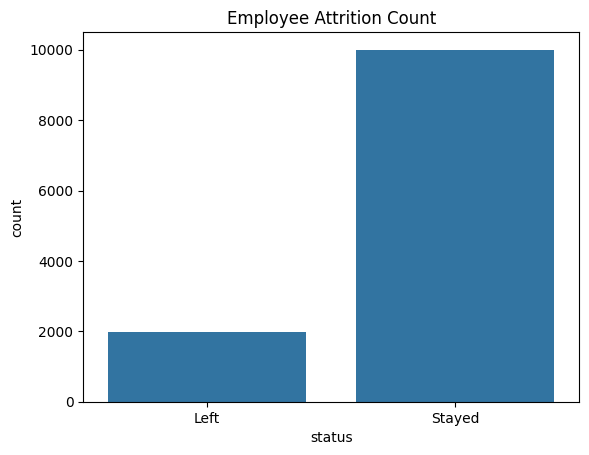

In [28]:

plt.title("Employee Attrition Count")
df['status'] = df['left'].map({0: 'Stayed', 1: 'Left'})
sns.countplot(x='status', data=df)
plt.show()


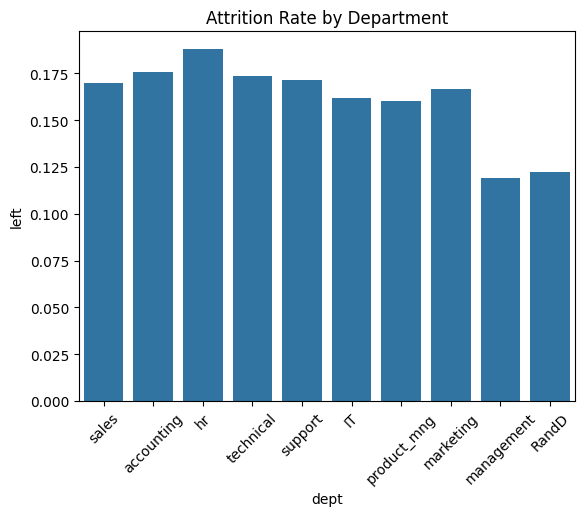

In [36]:
sns.barplot(x='dept', y='left', data=df,errorbar=None)
plt.title("Attrition Rate by Department")
plt.xticks(rotation=45)
plt.show()

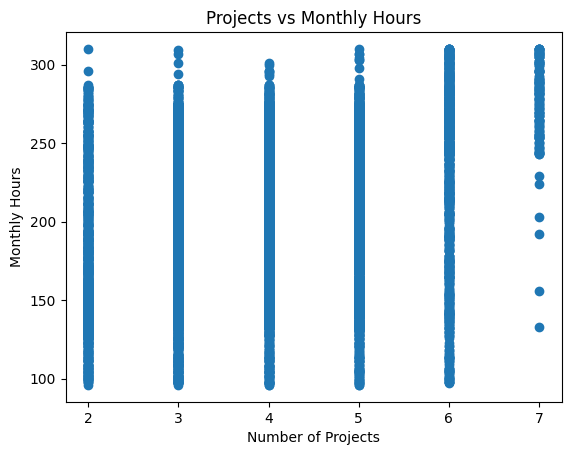

In [38]:
plt.scatter(df['numberOfProjects'], df['avgMonthlyHours'])
plt.title("Projects vs Monthly Hours")
plt.xlabel("Number of Projects")
plt.ylabel("Monthly Hours")
plt.show()

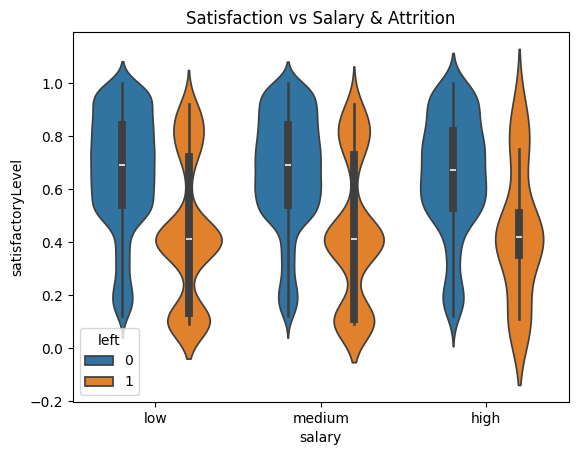

In [39]:
sns.violinplot(x='salary', y='satisfactoryLevel', hue='left', data=df)
plt.title("Satisfaction vs Salary & Attrition")
plt.show()

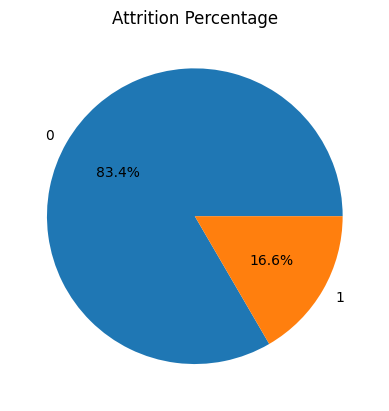

In [40]:
df['left'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Attrition Percentage")
plt.ylabel("")
plt.show()

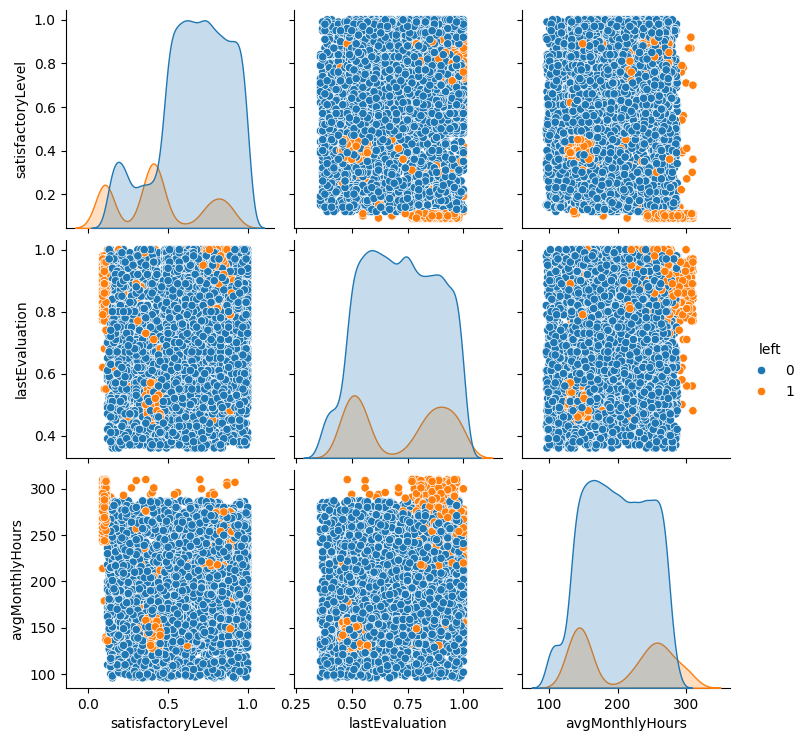

In [41]:
sns.pairplot(df[['satisfactoryLevel','lastEvaluation','avgMonthlyHours','left']], hue='left')
plt.show()

In [ ]:
dept_attrition = df.groupby('dept')['left'].mean() * 100
dept_attrition = dept_attrition.sort_values(ascending=False)
print(dept_attrition)

dept
hr             18.801997
accounting     17.552335
technical      17.379679
support        17.133443
sales          16.980550
marketing      16.641902
IT             16.188525
product_mng    16.034985
RandD          12.247839
management     11.926606
Name: left, dtype: float64


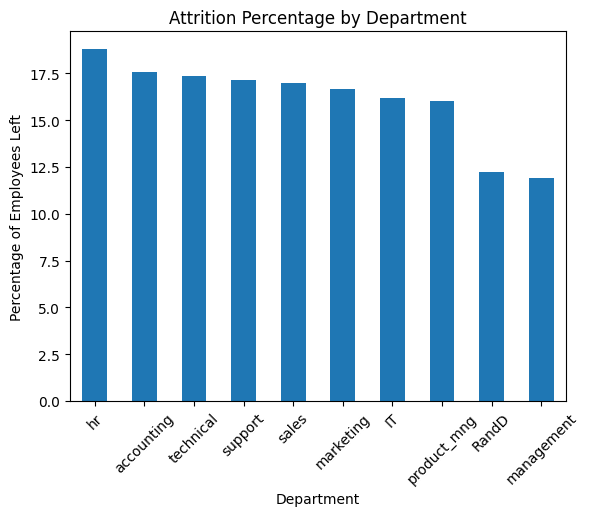

In [ ]:
dept_attrition.plot(kind='bar')
plt.title("Attrition Percentage by Department")
plt.xlabel("Department")
plt.ylabel("Percentage of Employees Left")
plt.xticks(rotation=45)
plt.show()

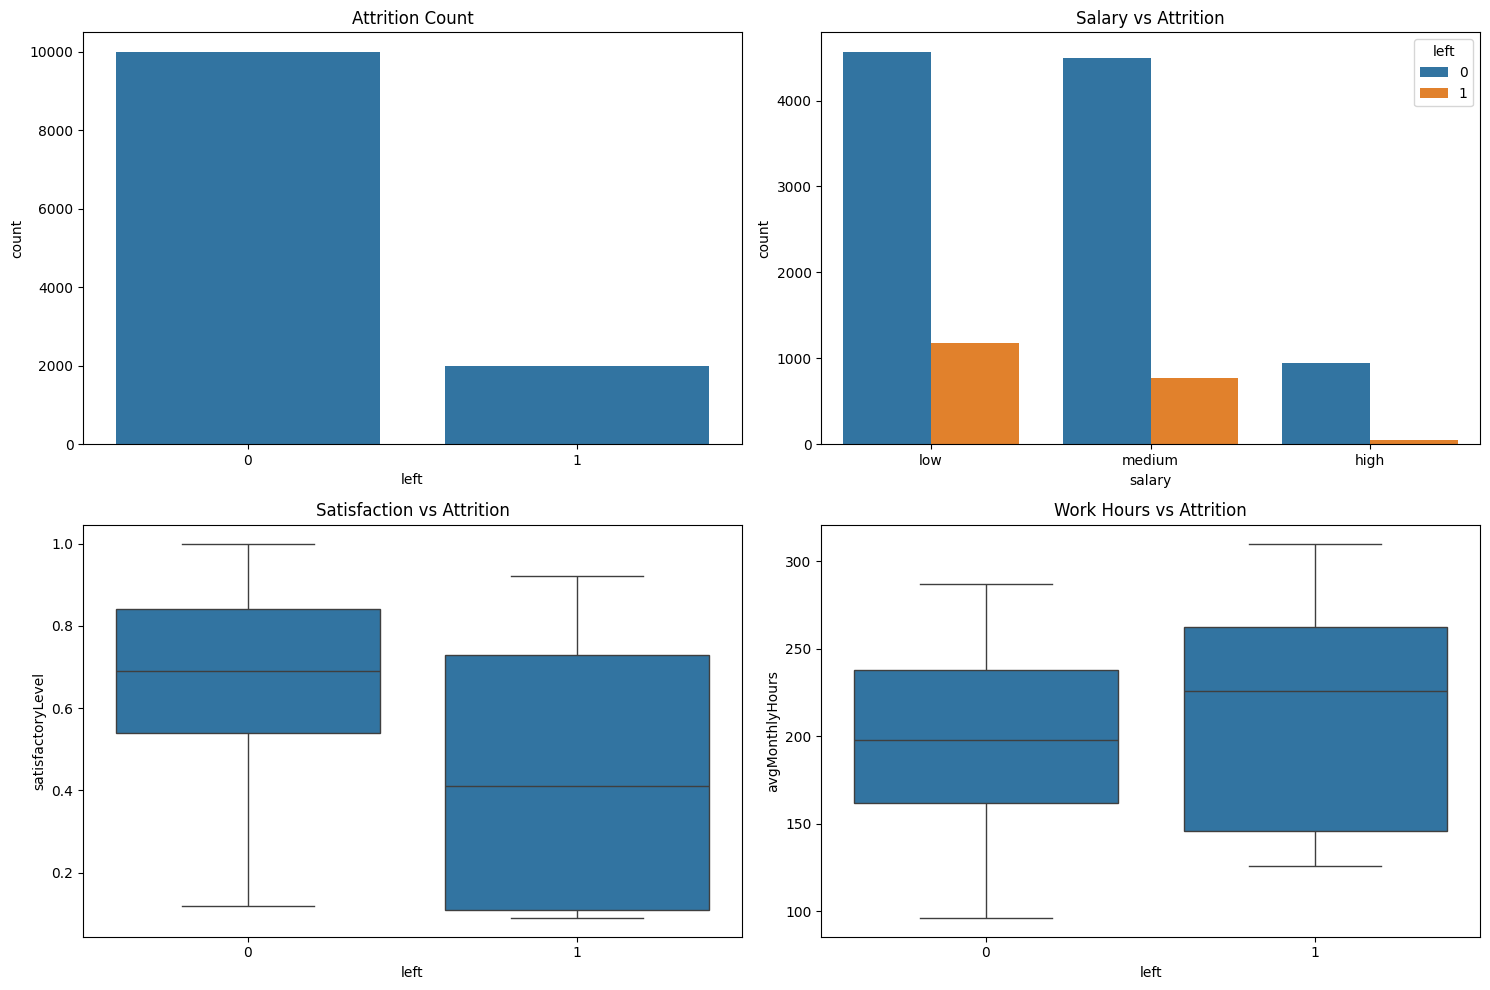

In [54]:
plt.figure(figsize=(15,10))

# 1 Attrition count
plt.subplot(2,2,1)
sns.countplot(x="left", data=df)
plt.title("Attrition Count")

# 2 Salary vs Attrition
plt.subplot(2,2,2)
sns.countplot(x="salary", hue="left", data=df)
plt.title("Salary vs Attrition")

# 3 Satisfaction vs Attrition
plt.subplot(2,2,3)
sns.boxplot(x="left", y="satisfactoryLevel", data=df)
plt.title("Satisfaction vs Attrition")

# 4 Work Hours
plt.subplot(2,2,4)
sns.boxplot(x="left", y="avgMonthlyHours", data=df)
plt.title("Work Hours vs Attrition")

plt.tight_layout()
plt.show()